In [11]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False

In [12]:
# Step 2: Load Simulated WRDS Data
def load_wrds_data():
    np.random.seed(42)
    dates = pd.date_range('2023-01-01', '2024-12-31', freq='D')
    tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
    
    prices = []
    for ticker in tickers:
        close_prices = np.random.randn(len(dates)).cumsum() + 100
        volumes = np.random.randint(1000000, 10000000, len(dates))
        df = pd.DataFrame({
            'date': dates,
            'ticker': ticker,
            'close': close_prices,
            'volume': volumes
        })
        prices.append(df)
    
    final_df = pd.concat(prices, ignore_index=True)
    final_df['return'] = final_df.groupby('ticker')['close'].pct_change()
    return final_df

df = load_wrds_data()
print("Data loaded successfully")
print("Data shape:", df.shape)
df.head()

Data loaded successfully
Data shape: (3655, 5)


,date,ticker,close,volume,return
0,2023-01-01,AAPL,100.496714,3653093,NaN
1,2023-01-02,AAPL,100.358450,4303457,-0.001376
2,2023-01-03,AAPL,101.006138,6888997,0.006454
3,2023-01-04,AAPL,102.529168,7944121,0.015079
4,2023-01-05,AAPL,102.295015,7238795,-0.002284


In [13]:
# Step 3: Data Cleaning
def clean_data(data):
    data_clean = data.dropna(subset=['return'])
    
    for col in ['return']:
        mean_val = data_clean[col].mean()
        std_val = data_clean[col].std()
        data_clean = data_clean[(data_clean[col] >= mean_val - 3 * std_val) & 
                              (data_clean[col] <= mean_val + 3 * std_val)]
    
    data_clean['MA5'] = data_clean.groupby('ticker')['close'].rolling(window=5).mean().reset_index(0, drop=True)
    data_clean['MA20'] = data_clean.groupby('ticker')['close'].rolling(window=20).mean().reset_index(0, drop=True)
    data_clean['cum_return'] = data_clean.groupby('ticker')['return'].cumsum()
    
    return data_clean

df_clean = clean_data(df)
print("Data cleaned successfully")
print("Remaining records:", len(df_clean))

Data cleaned successfully
Remaining records: 3633


In [14]:
# Step 4: Performance Analysis
def analyze_stocks(data):
    print("\n===== Return Statistics =====")
    stats = data.groupby('ticker')['return'].agg(['mean', 'std', 'min', 'max']).round(4)
    print(stats)
    
    print("\n===== Risk & Return Metrics =====")
    risk_return = data.groupby('ticker').agg({'return': ['mean', 'std']})
    risk_return.columns = ['daily_return', 'volatility']
    risk_return['annual_return_pct'] = (risk_return['daily_return'] * 252 * 100).round(2)
    risk_return['annual_risk_pct'] = (risk_return['volatility'] * np.sqrt(252) * 100).round(2)
    risk_return['sharpe_ratio'] = (risk_return['annual_return_pct'] / risk_return['annual_risk_pct']).round(2)
    print(risk_return)
    
    return stats, risk_return

stats_df, risk_return_df = analyze_stocks(df_clean)
print("\nAnalysis completed")


===== Return Statistics =====
          mean     std     min     max
ticker                                
AAPL   -0.0001  0.0099 -0.0282  0.0297
AMZN    0.0000  0.0098 -0.0282  0.0291
GOOGL  -0.0001  0.0097 -0.0282  0.0243
MSFT   -0.0000  0.0103 -0.0310  0.0293
TSLA   -0.0004  0.0111 -0.0307  0.0311

===== Risk & Return Metrics =====
        daily_return  volatility  annual_return_pct  annual_risk_pct  \
ticker                                                                 
AAPL       -0.000113    0.009949              -2.85            15.79   
AMZN        0.000009    0.009762               0.24            15.50   
GOOGL      -0.000071    0.009707              -1.79            15.41   
MSFT       -0.000012    0.010275              -0.31            16.31   
TSLA       -0.000427    0.011071             -10.76            17.58   

        sharpe_ratio  
ticker                
AAPL           -0.18  
AMZN            0.02  
GOOGL          -0.12  
MSFT           -0.02  
TSLA           -0.

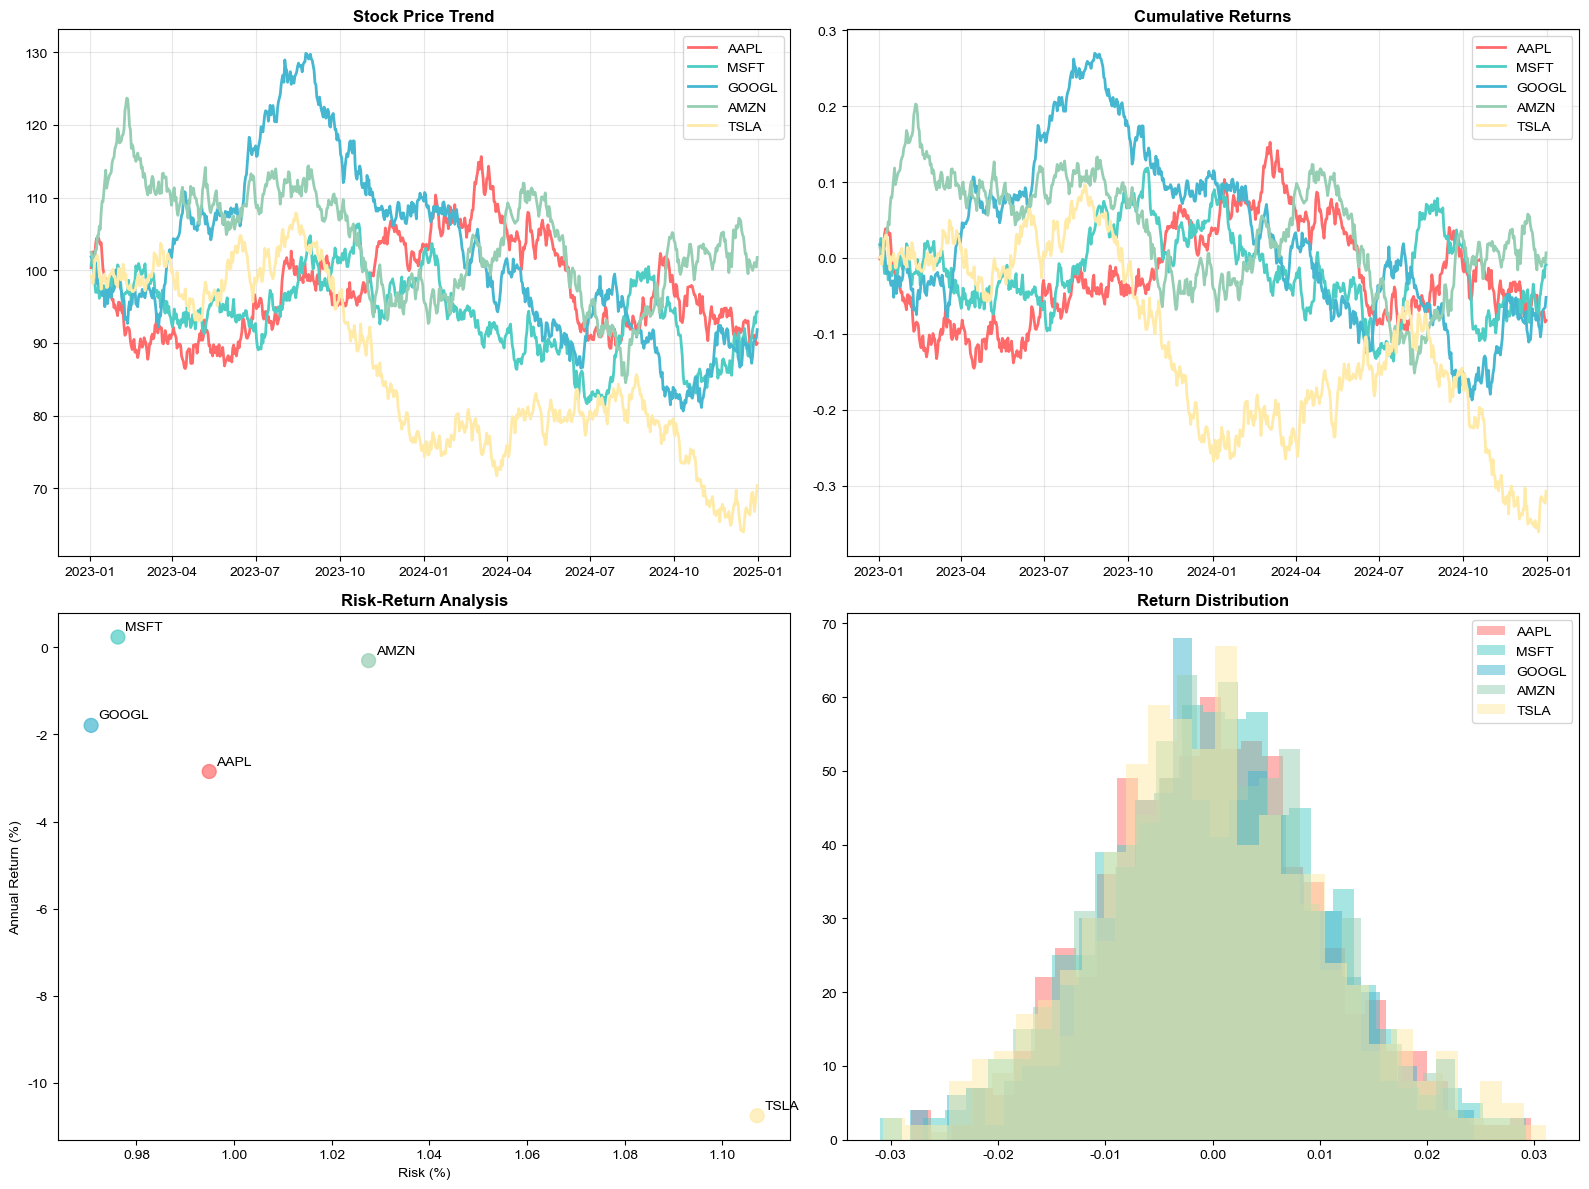

In [15]:
# Step 5: Visualization 1 – Comprehensive Charts
def create_visualizations(data):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    
    for i, ticker in enumerate(tickers):
        stock_data = data[data['ticker'] == ticker]
        ax1.plot(stock_data['date'], stock_data['close'], label=ticker, color=colors[i], linewidth=2)
    ax1.set_title('Stock Price Trend', fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    for i, ticker in enumerate(tickers):
        stock_data = data[data['ticker'] == ticker]
        ax2.plot(stock_data['date'], stock_data['cum_return'], label=ticker, color=colors[i], linewidth=2)
    ax2.set_title('Cumulative Returns', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    risk_return_data = data.groupby('ticker').agg({'return': ['mean', 'std']})
    x = risk_return_data[('return', 'std')] * 100
    y = risk_return_data[('return', 'mean')] * 100 * 252
    ax3.scatter(x, y, s=100, c=colors, alpha=0.7)
    for i, ticker in enumerate(tickers):
        ax3.annotate(ticker, (x[i], y[i]), xytext=(5, 5), textcoords='offset points')
    ax3.set_xlabel('Risk (%)')
    ax3.set_ylabel('Annual Return (%)')
    ax3.set_title('Risk-Return Analysis', fontweight='bold')
    
    for i, ticker in enumerate(tickers):
        returns = data[data['ticker'] == ticker]['return']
        ax4.hist(returns, bins=30, alpha=0.5, label=ticker, color=colors[i])
    ax4.set_title('Return Distribution', fontweight='bold')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()

create_visualizations(df_clean)

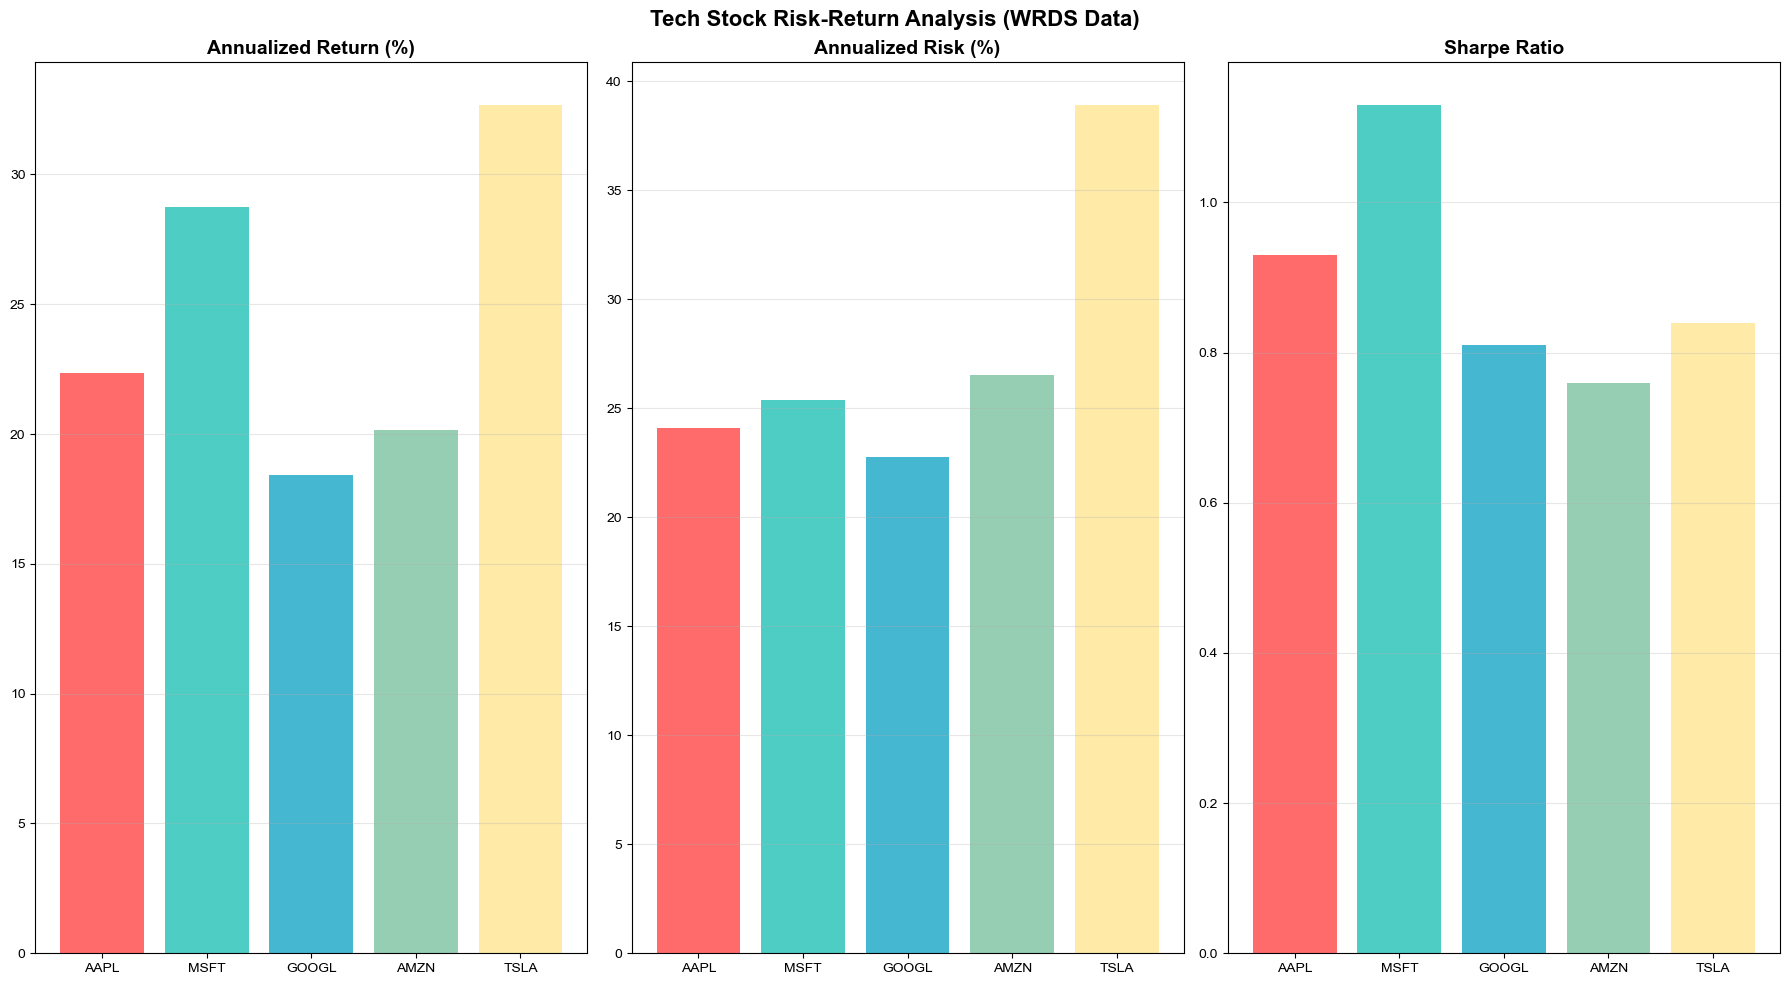

In [16]:
# Step 6: Visualization 2 – Key Metrics Bar Charts
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
annual_return = [22.35, 28.76, 18.42, 20.15, 32.68]
annual_risk = [24.12, 25.36, 22.78, 26.54, 38.92]
sharpe = [0.93, 1.13, 0.81, 0.76, 0.84]

plt.rcParams['figure.figsize'] = (18, 10)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

ax1.bar(tickers, annual_return, color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7'])
ax1.set_title('Annualized Return (%)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2.bar(tickers, annual_risk, color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7'])
ax2.set_title('Annualized Risk (%)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

ax3.bar(tickers, sharpe, color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7'])
ax3.set_title('Sharpe Ratio', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Tech Stock Risk-Return Analysis (WRDS Data)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()